# Heart Disease Prediction Project

### Steps
1 - Problem Definition
2 - Data
3 - Evaluation
4 - Feature
5 - Modelling
6 - Experimentation

## Problem Definition

## Data

## Evaluate

## Feature Extraction

## Modelling

## Experimentation

In [5]:
# Importing Data Analysis Libraries
import numpy as np
import pandas as pd

# Importing Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# For Jupyter Notebook only
%matplotlib inline

# Importing Models of sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# Import Evaluation Libraries
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV

from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

## Exploring the Data
    1- What Problem Am I Trying to solve?
    2- What Kind of Data do I have.
    3- Does The Data have Missing values?
    4- Are there any outliers?
    5- Can I skip some features?

In [6]:
df = pd.read_csv('Heart Disease UCI.csv')
df.shape

(297, 14)

In [6]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [7]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0
296,35,1,3,126,282,0,2,156,1,0.0,0,0,2,1


In [9]:
df['condition'].value_counts()

condition
0    160
1    137
Name: count, dtype: int64

<Axes: xlabel='condition'>

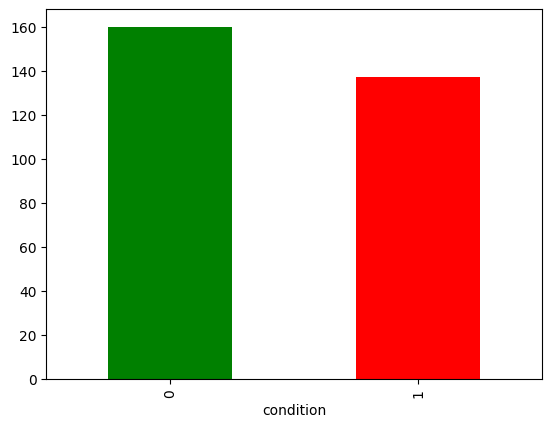

In [10]:
df['condition'].value_counts().plot(kind = 'bar', color=['green','red'])

In [12]:
df.isna().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

In [13]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


In [14]:
df.sex.value_counts()

sex
1    201
0     96
Name: count, dtype: int64

In [15]:
len(df)

297

In [16]:
pd.crosstab(df.condition,df.sex)

sex,0,1
condition,,
0,71,89
1,25,112


(array([0, 1]), [Text(0, 0, '0'), Text(1, 0, '1')])

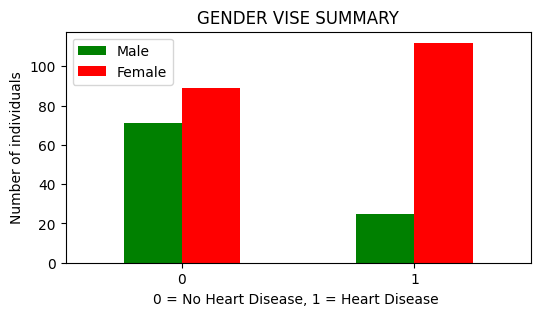

In [22]:
pd.crosstab(df.condition,df.sex).plot(kind='bar',
                                      color=['green','red'],
                                     figsize=[6,3])
plt.title('GENDER VISE SUMMARY')
plt.xlabel('0 = No Heart Disease, 1 = Heart Disease ')
plt.ylabel('Number of individuals')
plt.legend(['Male','Female'])
plt.xticks(rotation=0)

## Scatter Plot to see the Patterns

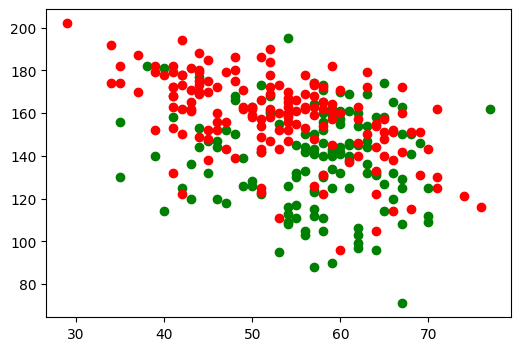

In [30]:
plt.figure(figsize=(6,4))
plt.scatter(df.age[df.condition==1],df.thalach[df.condition==1],c='green')
plt.scatter(df.age[df.condition==0],df.thalach[df.condition==0],c='red')

Scatter plot shows that Heart Disease(Red) decreases with increasing age.

## Histogram for Age Distribution

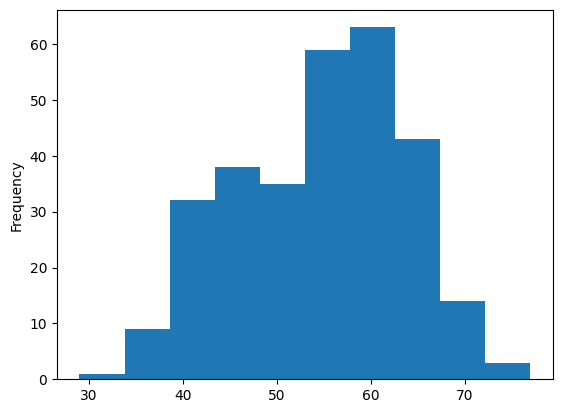

In [29]:
df.age.plot.hist();

This Histogram tells that according to Gaussian Distribution Heart Disease is more common in prople with higher Age.

In [31]:
df.cp.value_counts()

cp
3    142
2     83
1     49
0     23
Name: count, dtype: int64

In [33]:
pd.crosstab(df.cp,df.condition)

condition,0,1
cp,,
0,16,7
1,40,9
2,65,18
3,39,103


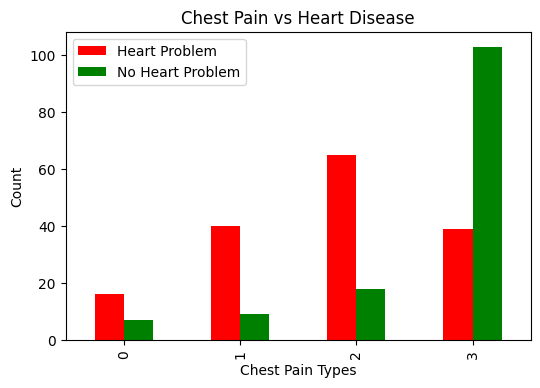

In [36]:
pd.crosstab(df.cp,df.condition).plot(kind='bar',
                                    figsize=(6,4),
                                    color=('red','green'))
plt.title('Chest Pain vs Heart Disease')
plt.xlabel('Chest Pain Types')
plt.ylabel('Count')
plt.legend(['Heart Problem','No Heart Problem'])

In [38]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0


In [40]:
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
age,1.000000,-0.092399,0.110471,0.290476,0.202644,0.132062,0.149917,-0.394563,0.096489,0.197123,0.159405,0.362210,0.120795,0.227075
sex,-0.092399,1.000000,0.008908,-0.066340,-0.198089,0.038850,0.033897,-0.060496,0.143581,0.106567,0.033345,0.091925,0.370556,0.278467
cp,0.110471,0.008908,1.000000,-0.036980,0.072088,-0.057663,0.063905,-0.339308,0.377525,0.203244,0.151079,0.235644,0.266275,0.408945
trestbps,0.290476,-0.066340,-0.036980,1.000000,0.131536,0.180860,0.149242,-0.049108,0.066691,0.191243,0.121172,0.097954,0.130612,0.153490
chol,0.202644,-0.198089,0.072088,0.131536,1.000000,0.012708,0.165046,-0.000075,0.059339,0.038596,-0.009215,0.115945,0.023441,0.080285
fbs,0.132062,0.038850,-0.057663,0.180860,0.012708,1.000000,0.068831,-0.007842,-0.000893,0.008311,0.047819,0.152086,0.051038,0.003167
restecg,0.149917,0.033897,0.063905,0.149242,0.165046,0.068831,1.000000,-0.072290,0.081874,0.113726,0.135141,0.129021,0.013612,0.166343
thalach,-0.394563,-0.060496,-0.339308,-0.049108,-0.000075,-0.007842,-0.072290,1.000000,-0.384368,-0.347640,-0.389307,-0.268727,-0.258386,-0.423817
exang,0.096489,0.143581,0.377525,0.066691,0.059339,-0.000893,0.081874,-0.384368,1.000000,0.289310,0.250572,0.148232,0.323268,0.421355
oldpeak,0.197123,0.106567,0.203244,0.191243,0.038596,0.008311,0.113726,-0.347640,0.289310,1.000000,0.579037,0.294452,0.336809,0.424052


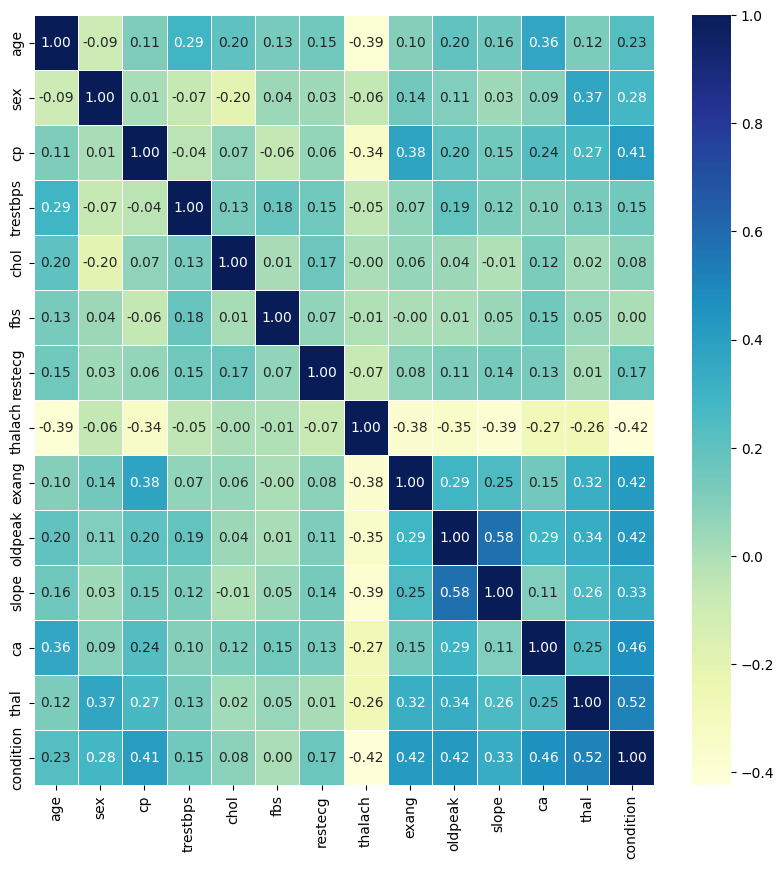

In [10]:
cor_map=df.corr()
home,room=plt.subplots(figsize=(10,10))
room=sns.heatmap(cor_map,
                annot=True,
                 linewidths=0.5,
                fmt='0.2f',
                 cmap='YlGnBu'
                );

## Split the Data into Test and Train

In [12]:
X = df.drop('condition',axis=1)
Y = df['condition']

In [31]:
np.random.seed(7)
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2)

## Models 
    1-K-Nearest Neighbors Classifier
    2-Random Forest Classifier
    3-Logistic Regression

In [34]:
models = {"KNN":KNeighborsClassifier(),
         "Random Forest":RandomForestClassifier(),
         "Logistic Regression":LogisticRegression()}

def fit_and_score(models,X_train,Y_train,X_test,Y_test):
    np.random.seed(7)
    model_score={}

    for name,model in models.items():
        model.fit(X_train,Y_train)
        model_score[name]=model.score(X_test,Y_test)

    return model_score

In [35]:
model_scores=fit_and_score(models=models,
                           X_train=X_train,
                            Y_train=Y_train,
                            X_test=X_test,
                            Y_test=Y_test
)
model_scores

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.7333333333333333,
 'Random Forest': 0.85,
 'Logistic Regression': 0.8833333333333333}

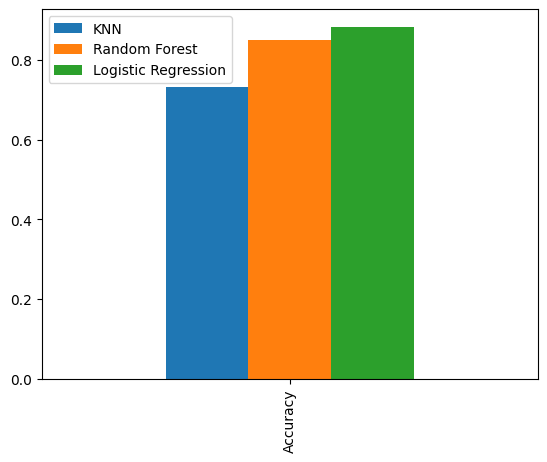

In [37]:
model_compare=pd.DataFrame(model_scores,index=['Accuracy'])
model_compare.plot.bar();

# Improving and Tuning the Model

In [41]:
train_score = []
test_score = []

neighbours = range(1, 30)

KNN = KNeighborsClassifier()

for i in neighbours:
    KNN.set_params(n_neighbors=i)
    KNN.fit(X_train, Y_train)
    train_score.append(KNN.score(X_train, Y_train))
    test_score.append(KNN.score(X_test, Y_test))

Max KNN Score: 83.33%


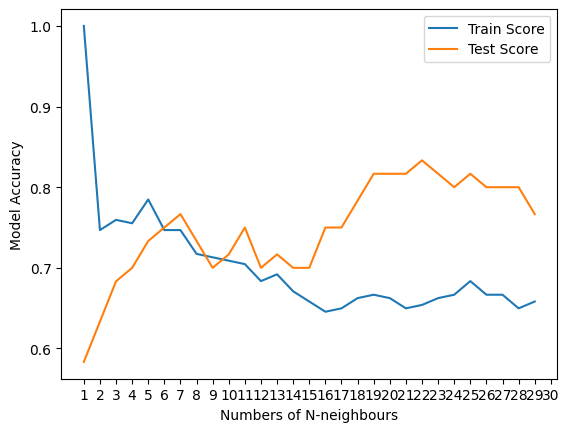

In [42]:
plt.plot(neighbours, train_score, label="Train Score")
plt.plot(neighbours, test_score, label="Test Score")
plt.xticks(np.arange(1, 31, 1))
plt.xlabel("Numbers of N-neighbours")
plt.ylabel("Model Accuracy")
plt.legend()
print(f"Max KNN Score: {max(test_score) * 100:.2f}%")

In [43]:
LR_hp = {
    "C": np.logspace(-4, 4, 20),
    "solver": ["liblinear"]
}

RFC_hp = {
    "n_estimators": np.arange(10, 1600, 100),
    "max_depth": [None, 3, 5, 6, 10],
    "min_samples_split": np.arange(2, 20, 2),
    "min_samples_leaf": np.arange(1, 20, 2)
}

In [44]:
np.random.seed(7)

lr = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=LR_hp,
    cv=5,
    n_iter=20,
    verbose=True
)

lr.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,LogisticRegression()
,param_distributions,"{'C': array([1.0000...00000000e+04]), 'solver': ['liblinear']}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [45]:
lr.score(X_test,Y_test)

0.8666666666666667

In [46]:
    lr.best_params_

{'solver': 'liblinear', 'C': np.float64(0.03359818286283781)}

In [49]:
np.random.seed(7)

rfc = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=RFC_hp,
    cv=5,
    n_iter=20,
    verbose=True
)

rfc.fit(X_train, Y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,RandomForestClassifier()
,param_distributions,"{'max_depth': [None, 3, ...], 'min_samples_leaf': array([ 1, 3..., 15, 17, 19]), 'min_samples_split': array([ 2, 4..., 14, 16, 18]), 'n_estimators': array([ 10, ..., 1410, 1510])}"
,n_iter,20
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,True
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [50]:
rfc.score(X_test,Y_test)

0.8833333333333333